# Classification des Caractères Tifinagh avec un Réseau de Neurones Multiclasses

** Réaliser par Chaymae Al-aissaoui **

Ce notebook implémente from scratch un
perceptron multicouche (MLP) pour classifier les 33 classes de l'alphabet
Tifinagh, a partir de la base **AMHCD** .

Architecture : `1024 -> 64 (ReLU) -> 32 (ReLU) -> 33 (Softmax)`

Toutes les fonctions ci-dessous suivent les formules mathématiques
données dans l'énoncé du TP.

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # reproductibilité globale

## 1. Les fonctions d'activation utilisées

- **ReLU** : $g(z) = \max(0, z)$ — Eq (3)
- **ReLU'** : $g'(z) = 1$ si $z>0$, sinon $0$ — Eq (9)
- **Softmax** : $\hat y_{i,c} = \dfrac{e^{z_{i,c}}}{\sum_{j=1}^{33} e^{z_{i,j}}}$ — Eq (4)

Pour la stabilité numérique du softmax, on soustrait le maximum de chaque
ligne avant d'exponentier

In [2]:
def relu(x):
    """
    ReLU activation : g(z) = max(0, z)   (Eq. 3)

    Parameters
    ----------
    x : np.ndarray
        Pre-activation Z

    Returns
    -------
    np.ndarray
        max(0, x), meme forme que x
    """
    assert isinstance(x, np.ndarray), "Input in ReLU must be a numpy array"
    result = np.maximum(0, x)
    assert np.all(result >= 0), "ReLU output must be non-negative"
    return result


def relu_derivative(x):
    """
    Dérivée de ReLU appliquée a Z :
        g'(z) = 1 si z > 0, sinon 0

    Parameters
    ----------
    x : np.ndarray
        La prE-activation Z sur laquelle on dérive

    Returns
    -------
    np.ndarray
        Masque binaire (0/1) de meme forme que x
    """
    assert isinstance(x, np.ndarray), "Input in ReLU derivation must be a numpy array"
    result = (x > 0).astype(float)
    assert np.all((result == 0) | (result == 1)), "ReLU derivation must be 0 or 1"
    return result


def softmax(x):
    """
    Softmax activation :

    On soustrait le max par ligne pour la stabilité numérique

    Parameters
    ----------
    x : np.ndarray, shape (m, n_classes)
        Pre-activation de la couche de sortie (Z3)

    Returns
    -------
    np.ndarray, shape (m, n_classes)
        Distribution de probabilité par ligne (somme = 1)
    """
    assert isinstance(x, np.ndarray), "Input to softmax must be a numpy array"
    x_stable = x - np.max(x, axis=1, keepdims=True)  # stabilité numérique
    exp_x = np.exp(x_stable)
    result = exp_x / np.sum(exp_x, axis=1, keepdims=True)
    assert np.all((result >= 0) & (result <= 1)), "Softmax output must be in [0, 1]"
    assert np.allclose(np.sum(result, axis=1), 1), "Softmax output must sum to 1 per sample"
    return result

## 2. Classe MultiClassNeuralNetwork

Implémente :
- **Forward** : $Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}$, $A^{[l]} = g^{[l]}(Z^{[l]})$ (Eq. 1-2)
- **Loss** : entropie croisée catégorielle (Eq. 5)
- **Accuracy** (Eq. 6)
- **Backward** :
  - Sortie : $\dfrac{\partial J}{\partial Z^{[3]}} = \hat y - Y$ (Eq. 7)
  - Couches cachées : $\dfrac{\partial J}{\partial Z^{[l]}} = \left(\dfrac{\partial J}{\partial Z^{[l+1]}} W^{[l+1]T}\right) \odot g'(Z^{[l]})$ (Eq. 8)
  - Gradients des poids/biais (Eq. 10-11) et mise à jour par descente de gradient (Eq. 12-13)

In [3]:
class MultiClassNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01):
        """
        Initialize the neural network with given layer sizes and learning rate.

        Parameters
        ----------
        layer_sizes : list[int]
            [input_size, hidden1_size, ..., output_size]
            Ex: [1024, 64, 32, 33].
        learning_rate : float
            Taux d'apprentissage eta (Eq. 12-13). Défaut 0.01
        """
        assert isinstance(layer_sizes, list) and len(layer_sizes) >= 2, \
            "layer_sizes must be a list with at least 2 elements"
        assert all(isinstance(size, int) and size > 0 for size in layer_sizes), \
            "All layer sizes must be positive integers"
        assert isinstance(learning_rate, (int, float)) and learning_rate > 0, \
            "Learning rate must be a positive number"

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []

        # Initialisation des poids et biais
        # W^[l] in R^{n^[l-1] x n^[l]}, b^[l] in R^{1 x n^[l]}
        # Petite échelle (*0.01) pour éviter des activations trop grandes au départ.
        np.random.seed(42)
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.01
            b = np.zeros((1, layer_sizes[i + 1]))
            assert w.shape == (layer_sizes[i], layer_sizes[i + 1]), \
                f"Weight matrix {i + 1} has incorrect shape"
            assert b.shape == (1, layer_sizes[i + 1]), \
                f"Bias vector {i + 1} has incorrect shape"
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        """
        Forward propagation :
            Z^[l] = A^[l-1] W^[l] + b^[l]     (Eq. 1)
            A^[l] = g^[l](Z^[l])               (Eq. 2)
        ReLU pour les couches cachées, Softmax pour la couche de sortie.

        Parameters
        ----------
        X : np.ndarray, shape (m, n_features)
            Batch d'entrée (A^[0] = X)

        Returns
        -------
        np.ndarray, shape (m, n_classes)
            Prédictions softmax (A^[3])
        """
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], \
            f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        self.activations = [X]
        self.z_values = []

        # Couches cachées (ReLU) : de la couche 1 a l'avant-derniere
        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            assert z.shape == (X.shape[0], self.layer_sizes[i + 1]), \
                f"Z^[{i + 1}] has incorrect shape"
            self.z_values.append(z)
            self.activations.append(relu(z))

        # Couche de sortie (Softmax)
        z = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        assert z.shape == (X.shape[0], self.layer_sizes[-1]), "Output Z has incorrect shape"
        self.z_values.append(z)
        output = softmax(z)
        assert output.shape == (X.shape[0], self.layer_sizes[-1]), "Output A has incorrect shape"
        self.activations.append(output)

        return self.activations[-1]

    def compute_loss(self, y_true, y_pred):
        """
        Categorical Cross-Entropy :
            J = -1/m * sum_i sum_c y_true_{i,c} * log(y_pred_{i,c})     (Eq. 5)

        Parameters
        ----------
        y_true : np.ndarray, shape (m, n_classes)
            Labels one-hot
        y_pred : np.ndarray, shape (m, n_classes)
            Predictions softmax

        Returns
        -------
        float
            Perte moyenne sur le batch
        """
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), \
            "Inputs to loss must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # évite log(0)
        loss = -np.sum(y_true * np.log(y_pred)) / m
        assert not np.isnan(loss), "Loss computation resulted in NaN"
        return loss

    def compute_accuracy(self, y_true, y_pred):
        """
        Compute accuracy : proportion de prédictions correctes.
            Accuracy = 1/m * sum_i [ argmax_c(y_pred_i) == argmax_c(y_true_i) ]   (Eq. 6)

        Parameters
        ----------
        y_true : np.ndarray, shape (m, n_classes)
            Labels one-hot
        y_pred : np.ndarray, shape (m, n_classes)
            Prédictions softmax

        Returns
        -------
        float
            Précision entre 0 et 1
        """
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), \
            "Inputs to accuracy must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        predictions = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        accuracy = np.mean(predictions == true_labels)
        assert 0 <= accuracy <= 1, "Accuracy must be between 0 and 1"
        return accuracy

    def backward(self, X, y, outputs, l2_lambda=0.0):
        """
        Backpropagation : calcule dW^[l], db^[l] pour chaque couche, puis
        met a jour les parametres par descente de gradient

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée utilisé pour le forward correspondant
        y : np.ndarray
            Labels one-hot du batch
        outputs : np.ndarray
            Sortie softmax renvoyée par `forward(X)`
        l2_lambda : float, optional
            Coefficient de régularisation L2. Si > 0, ajoute (lambda/m)*W^[l]
            au gradient des poids
        """
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray) and isinstance(outputs, np.ndarray), \
            "Inputs to backward must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], \
            f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape == outputs.shape, "y and outputs must have the same shape"

        m = X.shape[0]
        self.d_weights = [None] * len(self.weights)
        self.d_biases = [None] * len(self.biases)

        # --- Couche de sortie ---
        dZ = outputs - y  # Gradient pour softmax + cross-entropy (Eq. 7)
        assert dZ.shape == outputs.shape, "dZ for output layer has incorrect shape"
        self.d_weights[-1] = (self.activations[-2].T @ dZ) / m
        self.d_biases[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        # --- Couches cachées, en remontant (l = 2, 1, ...) ---
        for i in range(len(self.weights) - 2, -1, -1):
            dZ = (dZ @ self.weights[i + 1].T) * relu_derivative(self.z_values[i])
            assert dZ.shape == (X.shape[0], self.layer_sizes[i + 1]), \
                f"dZ^[{i + 1}] has incorrect shape"
            self.d_weights[i] = (self.activations[i].T @ dZ) / m
            self.d_biases[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # --- BONUS : régularisation L2 sur les gradients des poids ---
        # dW^[l] += (lambda / m) * W^[l]
        if l2_lambda > 0:
            for i in range(len(self.weights)):
                self.d_weights[i] += (l2_lambda / m) * self.weights[i]

        # --- Mise a jour des parametres (descente de gradient) ---
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.d_weights[i]
            self.biases[i] -= self.learning_rate * self.d_biases[i]

    def train(self, X, y, X_val, y_val, epochs, batch_size, l2_lambda=0.0, verbose_every=10):
        """
        Train the neural network using mini-batch SGD, avec suivi sur
        un ensemble de validation

        Parameters
        ----------
        X, y : np.ndarray
            Donnees et labels one-hot d'entrainement
        X_val, y_val : np.ndarray
            Donnees et labels one-hot de validation
        epochs : int
            Nombre d'époques
        batch_size : int
            Taille des mini-batchs
        l2_lambda : float (BONUS)
            Coefficient de régularisation L2, transmis a `backward`
        verbose_every : int
            Frequence (en époques) d'affichage des metriques

        Returns
        -------
        tuple of lists
            (train_losses, val_losses, train_accuracies, val_accuracies)
        """
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray), "X and y must be numpy arrays"
        assert isinstance(X_val, np.ndarray) and isinstance(y_val, np.ndarray), \
            "X_val and y_val must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], \
            f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape[1] == self.layer_sizes[-1], \
            f"Output dimension ({y.shape[1]}) must match output layer size ({self.layer_sizes[-1]})"
        assert X_val.shape[1] == self.layer_sizes[0], \
            f"Validation input dimension ({X_val.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y_val.shape[1] == self.layer_sizes[-1], \
            f"Validation output dimension ({y_val.shape[1]}) must match output layer size ({self.layer_sizes[-1]})"
        assert isinstance(epochs, int) and epochs > 0, "Epochs must be a positive integer"
        assert isinstance(batch_size, int) and batch_size > 0, "Batch size must be a positive integer"

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        for epoch in range(epochs):
            # Mélanger les données à chaque époque
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            n_batches = 0
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                outputs = self.forward(X_batch)
                epoch_loss += self.compute_loss(y_batch, outputs)
                self.backward(X_batch, y_batch, outputs, l2_lambda=l2_lambda)
                n_batches += 1

            # Metriques de fin d'epoque
            train_loss = epoch_loss / n_batches
            train_pred = self.forward(X)
            train_accuracy = self.compute_accuracy(y, train_pred)
            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(y_val, val_pred)
            val_accuracy = self.compute_accuracy(y_val, val_pred)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)

            if epoch % verbose_every == 0:
                print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
                      f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

        return train_losses, val_losses, train_accuracies, val_accuracies

    def predict(self, X):
        """
        Predict class labels (indices de classe, pas one-hot)

        Parameters
        ----------
        X : np.ndarray

        Returns
        -------
        np.ndarray, shape (m,)
            Classe predite pour chaque echantillon.
        """
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], \
            f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        outputs = self.forward(X)
        predictions = np.argmax(outputs, axis=1)
        assert predictions.shape == (X.shape[0],), "Predictions have incorrect shape"
        return predictions

## 3. Chargement et pretraitement des donnees AMHCD

la base de données AMHCD et
décompresser-la de façon à avoir un dossier `amhcd-data-64/tifinagh-images/`
contenant les sous-dossiers de classes (ou un fichier `labels-map.csv`)
à la racine de ce notebook. Adaptez `data_dir` si nécessaire.

In [8]:
import kagglehub

# Télécharger la dernière version du dataset (mis en cache localement sur le disque de la VM)
path = kagglehub.dataset_download("benaddym/amazigh-handwritten-character-database-amhcd")
print("Path to dataset files:", path)

data_dir = path
print("Contenu de data_dir:")
print(os.listdir(data_dir))

100%|██████████| 67.9M/67.9M [00:00<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/benaddym/amazigh-handwritten-character-database-amhcd/versions/1
Contenu de data_dir:
['AMHCD_64', 'labels', 'amhcd_64']


In [14]:
tifinagh_dir = os.path.join(data_dir, "AMHCD_64", "AMHCD_64")
assert os.path.exists(tifinagh_dir), f"Tifinagh images directory not found: {tifinagh_dir}"

print("Construction du DataFrame depuis l'arborescence des dossiers...")
image_paths, labels = [], []
for label_dir in os.listdir(tifinagh_dir):
    label_path = os.path.join(tifinagh_dir, label_dir)
    if os.path.isdir(label_path):
        for img_name in os.listdir(label_path):
            image_paths.append(os.path.join(label_dir, img_name))  # chemin relatif à tifinagh_dir
            labels.append(label_dir)
labels_df = pd.DataFrame({'image_path': image_paths, 'label': labels})

assert not labels_df.empty, "No data loaded. Check dataset files."
print(f"Loaded {len(labels_df)} samples with {labels_df['label'].nunique()} unique classes.")

Construction du DataFrame depuis l'arborescence des dossiers...
Loaded 25740 samples with 33 unique classes.


In [15]:
def load_and_preprocess_image(image_path, root_dir, target_size=(32, 32)):
    """
    Charge une image, la convertit en niveaux de gris, la redimensionne
    en 32x32, la normalise dans [0, 1], puis l'aplatit en vecteur 1D
    de 1024 features (conforme à l'entrée du MLP, section Introduction).
    """
    full_path = os.path.join(root_dir, image_path)
    assert os.path.exists(full_path), f"Image not found: {full_path}"
    img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"Failed to load image: {full_path}"
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return img.flatten()

In [16]:
X = np.array([load_and_preprocess_image(path, tifinagh_dir) for path in labels_df['image_path']])
y_labels_text = labels_df['label'].values

# Encoder les étiquettes texte -> entiers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels_text)
num_classes = len(label_encoder.classes_)

assert X.shape[0] == y.shape[0], "Mismatch between number of images and labels"
assert X.shape[1] == 32 * 32, f"Expected flattened image size of {32*32}, got {X.shape[1]}"
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (25740, 1024) | y shape: (25740,)


## 5. Split train / validation / test et encodage one-hot

- 80% train+val / 20% test, puis 75%/25% sur train+val => **60% train, 20% val, 20% test**, stratifié par classe.

In [17]:
# Diviser en ensembles d'entrainement, validation et test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Convertir explicitement en NumPy arrays
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == X.shape[0], \
    "Train-val-test split sizes must sum to total samples"

print(f"Train: {X_train.shape[0]} samples, Validation: {X_val.shape[0]} samples, "
      f"Test: {X_test.shape[0]} samples")

Train: 15444 samples, Validation: 5148 samples, Test: 5148 samples


In [18]:
# Encoder les etiquettes en one-hot pour la classification multiclasse
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = np.array(one_hot_encoder.fit_transform(y_train.reshape(-1, 1)))
y_val_one_hot = np.array(one_hot_encoder.transform(y_val.reshape(-1, 1)))
y_test_one_hot = np.array(one_hot_encoder.transform(y_test.reshape(-1, 1)))

# Vérifier que les tableaux one-hot sont des NumPy arrays
assert isinstance(y_train_one_hot, np.ndarray), "y_train_one_hot must be a numpy array"
assert isinstance(y_val_one_hot, np.ndarray), "y_val_one_hot must be a numpy array"
assert isinstance(y_test_one_hot, np.ndarray), "y_test_one_hot must be a numpy array"

print("y_train_one_hot shape:", y_train_one_hot.shape)

y_train_one_hot shape: (15444, 33)


## 6. Création et entraînement du modèle

In [19]:
# Créer et entrainer le modèle
layer_sizes = [X_train.shape[1], 64, 32, num_classes]  # 64 et 32 neurones cachés, 33 classes
nn = MultiClassNeuralNetwork(layer_sizes, learning_rate=0.01)

train_losses, val_losses, train_accuracies, val_accuracies = nn.train(
    X_train, y_train_one_hot, X_val, y_val_one_hot,
    epochs=100, batch_size=32
)

Epoch 0, Train Loss: 3.4966, Val Loss: 3.4965, Train Acc: 0.0306, Val Acc: 0.0303
Epoch 10, Train Loss: 3.4964, Val Loss: 3.4963, Train Acc: 0.0809, Val Acc: 0.0785
Epoch 20, Train Loss: 3.4934, Val Loss: 3.4924, Train Acc: 0.0477, Val Acc: 0.0484
Epoch 30, Train Loss: 2.8223, Val Loss: 3.1780, Train Acc: 0.0655, Val Acc: 0.0643
Epoch 40, Train Loss: 2.1365, Val Loss: 2.3298, Train Acc: 0.2260, Val Acc: 0.2224
Epoch 50, Train Loss: 1.4826, Val Loss: 1.4448, Train Acc: 0.5208, Val Acc: 0.5153
Epoch 60, Train Loss: 0.9381, Val Loss: 0.9572, Train Acc: 0.7110, Val Acc: 0.6999
Epoch 70, Train Loss: 0.6773, Val Loss: 0.6427, Train Acc: 0.8245, Val Acc: 0.8139
Epoch 80, Train Loss: 0.5730, Val Loss: 0.5987, Train Acc: 0.8385, Val Acc: 0.8271
Epoch 90, Train Loss: 0.4783, Val Loss: 0.5604, Train Acc: 0.8417, Val Acc: 0.8273


**Bonus — Régularisation L2** : pour l'activer, il suffit de relancer
l'entraînement avec `l2_lambda > 0`, par exemple :
```python
nn_l2 = MultiClassNeuralNetwork(layer_sizes, learning_rate=0.01)
nn_l2.train(X_train, y_train_one_hot, X_val, y_val_one_hot,
            epochs=100, batch_size=32, l2_lambda=0.01)
```
L'implémentation dans `backward()` ajoute `(lambda/m) * W^[l]` au gradient
des poids, conformément à la formule donnée dans le TP.

## 7. Prédictions et évaluation sur le test set

In [20]:
# Prédictions et évaluation
y_pred = nn.predict(X_test)
print("\nRapport de classification (Test set) :")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Rapport de classification (Test set) :
              precision    recall  f1-score   support

          ya       1.00      0.99      1.00       156
         yab       0.97      0.93      0.95       156
        yach       0.95      0.83      0.88       156
         yad       0.97      0.80      0.88       156
        yadd       0.62      0.65      0.64       156
         yae       0.92      0.94      0.93       156
         yaf       0.92      0.94      0.93       156
         yag       0.83      0.91      0.87       156
        yagh       0.87      0.99      0.93       156
        yagw       0.91      0.87      0.89       156
         yah       0.96      0.83      0.89       156
        yahh       0.68      0.89      0.77       156
         yaj       0.91      0.90      0.91       156
         yak       0.78      0.88      0.83       156
        yakw       0.96      0.81      0.88       156
         yal       0.97      0.83      0.90       156
         yam       0.90      0.63      0.

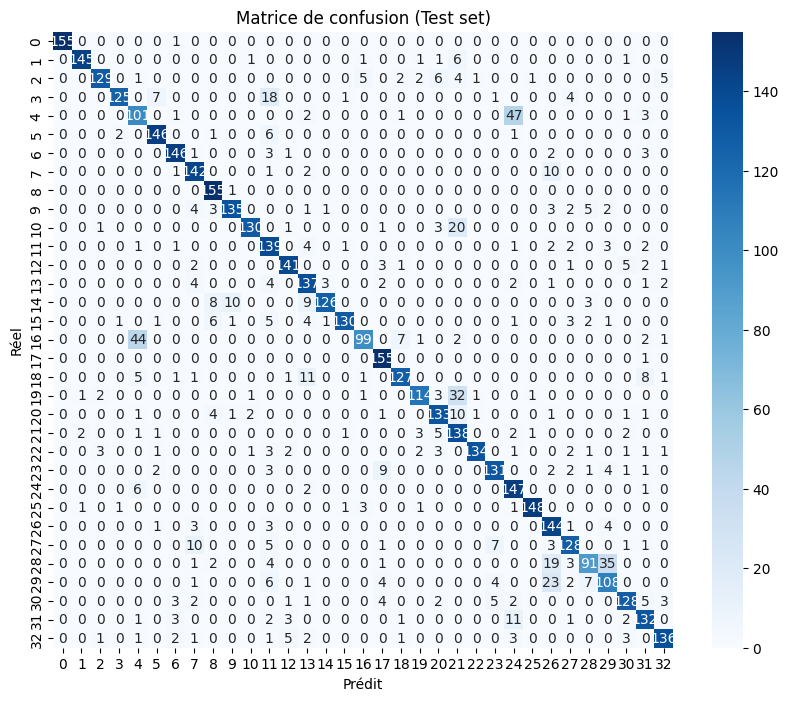

In [21]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (Test set)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.savefig('confusion_matrix.png')
plt.show()

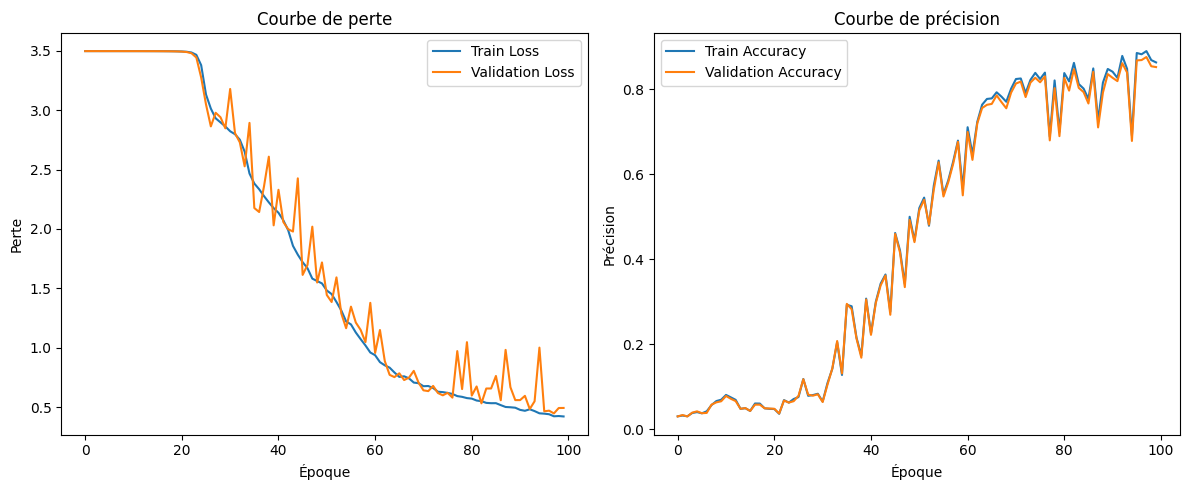

In [22]:
# Courbes de perte et d'accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Courbe de perte
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Courbe de perte')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Perte')
ax1.legend()

# Courbe d'accuracy
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Courbe de précision')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Précision')
ax2.legend()

plt.tight_layout()
fig.savefig('loss_accuracy_plot.png')
plt.show()